# Import Necessary Libraries

In [2]:
# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Model Saving
import joblib

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Load Dataset

In [4]:
df = pd.read_csv("dataset.csv")

df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


# Dataset Shape and Columns

In [6]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset Shape: (383, 17)

Columns:
Index(['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred'],
      dtype='object')


# Check Data Types

In [8]:
print(df.dtypes)

Age                      int64
Gender                  object
Smoking                 object
Hx Smoking              object
Hx Radiothreapy         object
Thyroid Function        object
Physical Examination    object
Adenopathy              object
Pathology               object
Focality                object
Risk                    object
T                       object
N                       object
M                       object
Stage                   object
Response                object
Recurred                object
dtype: object


# Check Missing Values

In [10]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64


# Target Distribution

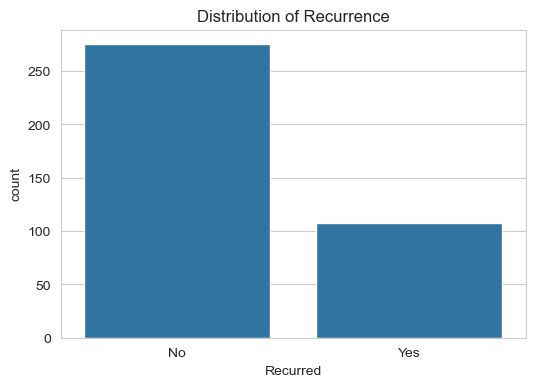

Recurred
No     275
Yes    108
Name: count, dtype: int64


In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Recurred', data=df)
plt.title("Distribution of Recurrence")
plt.show()

print(df['Recurred'].value_counts())

# Age Distribution

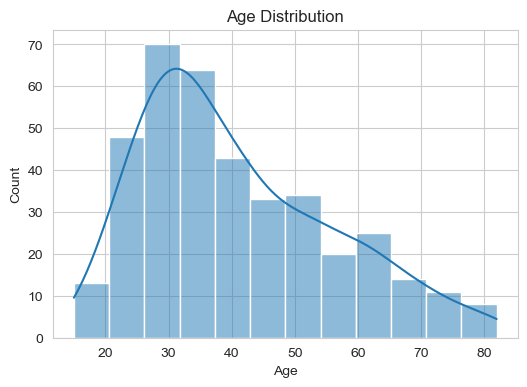

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Gender Distribution

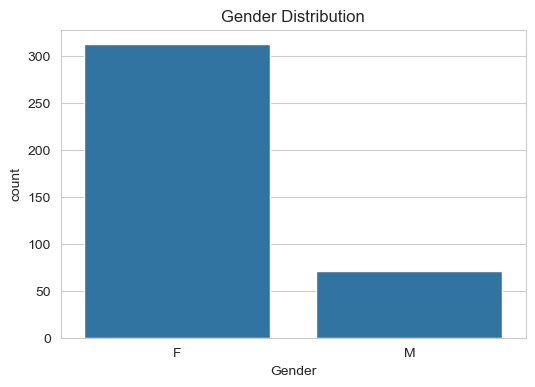

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Risk Category vs Recurrence

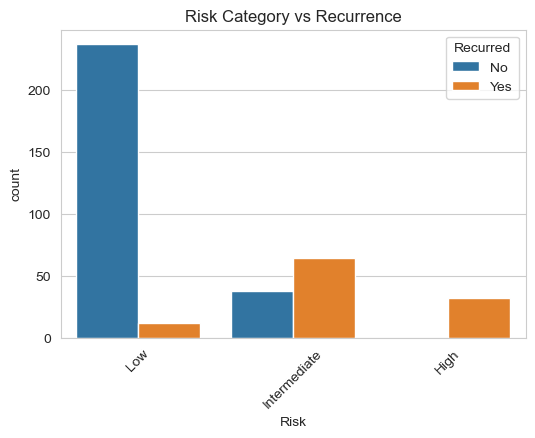

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='Risk', hue='Recurred', data=df)
plt.title("Risk Category vs Recurrence")
plt.xticks(rotation=45)
plt.show()

# Stage vs Recurrence

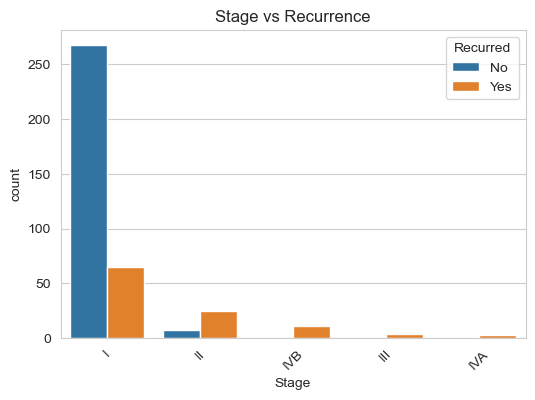

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='Stage', hue='Recurred', data=df)
plt.title("Stage vs Recurrence")
plt.xticks(rotation=45)
plt.show()

# Separate Features and Target

In [22]:
X = df.drop('Recurred', axis=1)
y = df['Recurred']

In [23]:
X.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent


# Encode Target (Yes=1, No=0)

In [25]:
y = y.map({'Yes': 1, 'No': 0})

# Identify Categorical & Numerical Columns

In [27]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:\n", categorical_cols)
print("\nNumerical Columns:\n", numerical_cols)

Categorical Columns:
 Index(['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response'],
      dtype='object')

Numerical Columns:
 Index(['Age'], dtype='object')


# One-Hot Encode Categorical Features

In [29]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_encoded.head()

,Age,Gender_M,Smoking_Yes,Hx Smoking_Yes,Hx Radiothreapy_Yes,Thyroid Function_Clinical Hypothyroidism,Thyroid Function_Euthyroid,Thyroid Function_Subclinical Hyperthyroidism,Thyroid Function_Subclinical Hypothyroidism,Physical Examination_Multinodular goiter,Physical Examination_Normal,Physical Examination_Single nodular goiter-left,Physical Examination_Single nodular goiter-right,Adenopathy_Extensive,Adenopathy_Left,Adenopathy_No,Adenopathy_Posterior,Adenopathy_Right,Pathology_Hurthel cell,Pathology_Micropapillary,Pathology_Papillary,Focality_Uni-Focal,Risk_Intermediate,Risk_Low,T_T1b,T_T2,T_T3a,T_T3b,T_T4a,T_T4b,N_N1a,N_N1b,M_M1,Stage_II,Stage_III,Stage_IVA,Stage_IVB,Response_Excellent,Response_Indeterminate,Response_Structural Incomplete
0,27,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,34,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,30,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,62,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,62,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


# Split Data into Train and Test Sets

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (306, 40)
Testing Shape: (77, 40)


# Initialize XGBoost Classifier

In [33]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train The Model

In [35]:
xgb_model.fit(X_train, y_train)

print("XGBoost Model Training Completed.")

XGBoost Model Training Completed.


# Predictions on Test Data

In [37]:
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate Evaluation Metrics

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.974025974025974
Precision: 1.0
Recall: 0.9090909090909091
F1 Score: 0.9523809523809523

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        55
           1       1.00      0.91      0.95        22

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.97        77
weighted avg       0.97      0.97      0.97        77



# Confusion Matrix

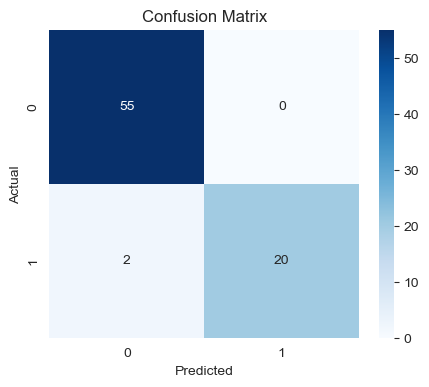

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC-AUC Score

In [43]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9950413223140495


# Plot ROC Curve

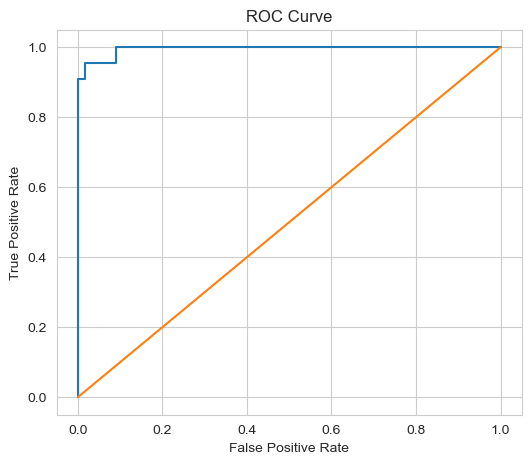

In [45]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [46]:
# Get probability for both classes
proba_full = xgb_model.predict_proba(X_test)

comparison_df_full = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability_No (%)': proba_full[:, 0] * 100,
    'Probability_Yes (%)': proba_full[:, 1] * 100
})

comparison_df_full.head(10)

,Actual,Predicted,Probability_No (%),Probability_Yes (%)
0,0,0,99.648499,0.351502
1,0,0,99.625641,0.374357
2,1,1,0.892341,99.107658
3,0,0,90.683098,9.316904
4,0,0,99.767426,0.232575
5,0,0,99.515007,0.484994
6,1,1,1.064783,98.935219
7,0,0,99.337097,0.662900
8,0,0,99.055214,0.944785
9,0,0,84.641884,15.358112


# Save Model

In [48]:
joblib.dump(xgb_model, "thyroid_recurrence_model.pkl")

print("Model Saved Successfully.")

Model Saved Successfully.
